# Una vacuna hizo que monos fabricaran anticuerpos contra el VIH

Durante casi 40 años, el VIH ganó una carrera: muta tan rápido que ninguna vacuna consiguió que un animal normal produjera los anticuerpos raros que sí frenan muchas cepas a la vez. En 2026, un equipo probó una estrategia distinta —guiar a las células B desde su versión más joven— en monos (primates no humanos *outbred*, es decir, genéticamente diversos como nosotros). Y por primera vez funcionó de forma reproducible.

Aquí abrimos los datos de **unión** anticuerpo–virus que el equipo publicó y miramos cómo esos anticuerpos maduraron, a qué se pegan exactamente, y qué firma estructural comparten.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Vaccination elicits HIV broadly neutralizing antibodies in primates* — Nature (2026).
**DOI:** [10.1038/s41586-026-10837-5](https://doi.org/10.1038/s41586-026-10837-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-08-vacuna-hiv-anticuerpos-primates/notebook.ipynb)

## Qué estamos mirando

Algunas personas con VIH, tras años de infección, terminan fabricando **anticuerpos ampliamente neutralizantes** (bnAbs): defensas capaces de bloquear muchas variantes del virus a la vez. El sueño de una vacuna es provocarlos *sin* infectar. El problema: las células B que pueden dar origen a esos anticuerpos son rarísimas.

La estrategia de este paper —*germline-targeting*— es un cebador diseñado para enganchar justo a esas células precursoras y, con refuerzos posteriores, empujar su maduración en la dirección correcta.

Un aviso de honestidad antes de graficar: los datos abiertos que abrimos aquí miden **unión** (qué tan fuerte se pega un anticuerpo a una proteína del virus, medido por SPR). La **neutralización** —matar al virus de verdad— vive en tablas del material suplementario que no son públicas. La unión es el paso previo mecánico a neutralizar, así que la seguimos como pista; pero **no** vamos a atribuirnos los porcentajes de neutralización del paper. Vamos a mirar tres cosas que sus datos sí nos dejan revisar:

1. **La maduración**: ¿a cuántos VIH distintos se pega un anticuerpo, semana a semana?
2. **La diana**: ¿le apuntan al epítopo que el diseño buscaba?
3. **La firma**: ¿comparten la forma estructural que se necesita para funcionar?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_UNION = 1e-6          # Kd (molar) por debajo del cual decimos "se une" (1 µM)
PANEL_AISLADOS = 11          # nº de aislados clínicos de VIH en el panel de prueba
SEMANA_CLAVE = 82            # semana de máxima amplitud mediana
FUENTE = 'Fuente: Nature (2026), DOI 10.1038/s41586-026-10837-5 | Datos: Supplementary Data 1-2'

COLOR_DATOS = '#2563EB'      # azul CaM — unión / anticuerpos
COLOR_ALERTA = '#DC2626'     # rojo — pierde unión / VIH que resisten
COLOR_SECUND = '#059669'     # emerald
COLOR_REFERENCIA = '#D97706' # amber — umbrales, referencias
COLOR_VIOLETA = '#7C3AED'
COLOR_GRIS = '#BBBBBB'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Carga de datasets (Supplementary Data del mismo DOI)
amp = pd.read_csv('datos/amplitud_por_semana.csv')          # maduración de amplitud
uni = pd.read_csv('datos/union_por_aislado.csv')            # amplitud por aislado
ctrl = pd.read_csv('datos/control_n332.csv')                # control del glicano N332
cdr = pd.read_csv('datos/cdr3_longitudes.csv')              # firma HCDR3
kd = pd.read_csv('datos/kd_matrix.csv')                     # matriz Kd larga (SPR)
kd['semana'] = pd.to_numeric(kd['semana'], errors='coerce') # w56 viene sin normalizar -> NaN

# El cebador (prime): ¿qué tan fuerte engancha a los precursores?
prime = kd[kd['inmunogeno'] == 'N332-GT5 gp140']['kd_molar']
prime_mediana_pM = prime.median() * 1e12
prime_pct_sub_1uM = 100 * (prime < UMBRAL_UNION).mean()

print(f'Matriz Kd (SPR): {len(kd):,} mediciones'.replace(',', '.'))
print(f'Cebador N332-GT5: {len(prime)} anticuerpos | Kd mediana = {prime_mediana_pM:.0f} pM '
      f'| {prime_pct_sub_1uM:.0f}% se unen (<1 µM)')
print(f'Panel de prueba: {PANEL_AISLADOS} aislados clínicos de VIH')
print(f'Firma HCDR3: {len(cdr)} anticuerpos de {cdr["nhp_id"].nunique()} primates')

Matriz Kd (SPR): 3.348 mediciones
Cebador N332-GT5: 239 anticuerpos | Kd mediana = 57 pM | 100% se unen (<1 µM)
Panel de prueba: 11 aislados clínicos de VIH
Firma HCDR3: 292 anticuerpos de 17 primates


## La maduración

Aquí está.

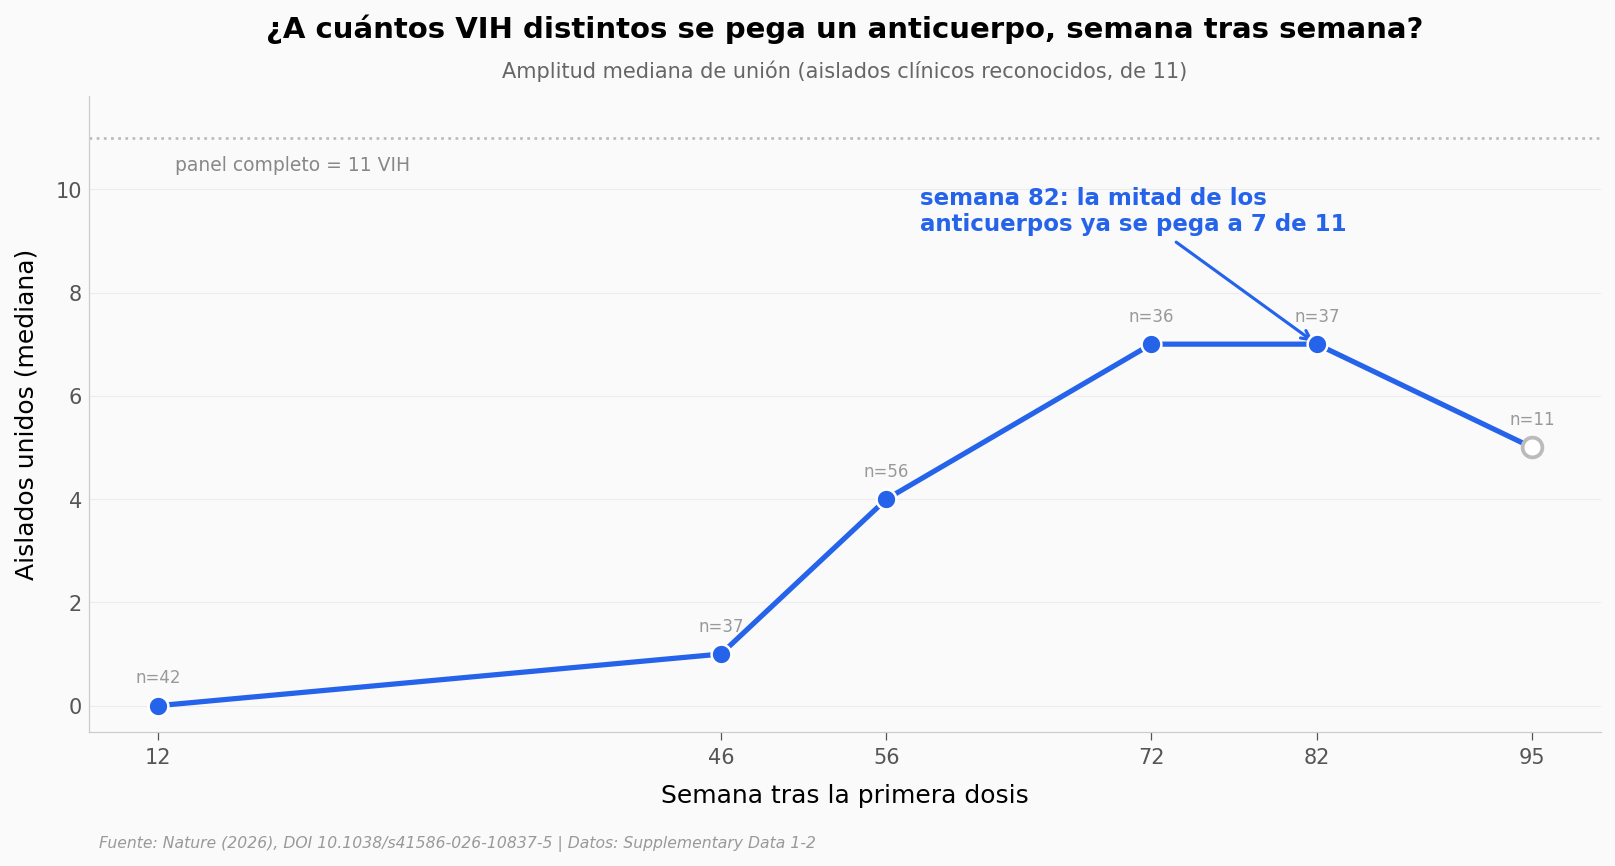

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Marcador hueco/gris para wk95 (n=11, submuestra) — no sobre-interpretar
es_wk95 = amp['semana'] == 95
ax.plot(amp['semana'], amp['amplitud_mediana'], color=COLOR_DATOS, lw=2.5, zorder=4)
ax.scatter(amp.loc[~es_wk95, 'semana'], amp.loc[~es_wk95, 'amplitud_mediana'],
           color=COLOR_DATOS, s=90, edgecolors='white', linewidths=1.2, zorder=5)
ax.scatter(amp.loc[es_wk95, 'semana'], amp.loc[es_wk95, 'amplitud_mediana'],
           facecolors='white', edgecolors=COLOR_GRIS, s=90, linewidths=1.8, zorder=5)

# Techo del panel
ax.axhline(PANEL_AISLADOS, color=COLOR_GRIS, ls=':', lw=1.3)
ax.text(13, PANEL_AISLADOS - 0.35, f'panel completo = {PANEL_AISLADOS} VIH',
        fontsize=9, color='#888888', va='top')

# n por punto
for _, r in amp.iterrows():
    ax.annotate(f"n={int(r['n_anticuerpos'])}", (r['semana'], r['amplitud_mediana']),
                textcoords='offset points', xytext=(0, 11), ha='center',
                fontsize=8, color='#999999')

ax.annotate('semana 82: la mitad de los\nanticuerpos ya se pega a 7 de 11',
            xy=(82, 7), xytext=(58, 9.2), fontsize=11, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))

ax.set_title('¿A cuántos VIH distintos se pega un anticuerpo, semana tras semana?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Amplitud mediana de unión (aislados clínicos reconocidos, de 11)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Semana tras la primera dosis')
ax.set_ylabel('Aislados unidos (mediana)')
ax.set_ylim(-0.5, 11.8)
ax.set_xticks(amp['semana'])
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/maduracion_amplitud.png', dpi=200, bbox_inches='tight')
plt.show()

Al principio, nada: en la semana 12 el anticuerpo mediano no reconoce ni un solo aislado del panel. Después la curva sube sola —1, luego 4— hasta que en la semana 82 la mitad de los anticuerpos se pega a 7 de los 11 VIH de prueba. Eso es lo que hace el diseño: no fabrica amplitud de golpe, la va guiando refuerzo tras refuerzo.

El punto hueco de la semana 95 baja, pero está sostenido por solo 11 anticuerpos (frente a 36–56 en las semanas previas): es una submuestra, probablemente de otro compartimento de memoria, así que no la leemos como una caída real. La tendencia sólida es la de la semana 12 a la 82.

## ¿Le apuntan al blanco correcto?

Que un anticuerpo se pegue al VIH no basta: el diseño buscaba un punto muy concreto de la envoltura del virus, un supersitio que depende de un azúcar llamado **glicano N332**. Si de verdad le apuntan ahí, quitar ese azúcar debería tumbar la unión. El equipo hizo exactamente esa prueba.

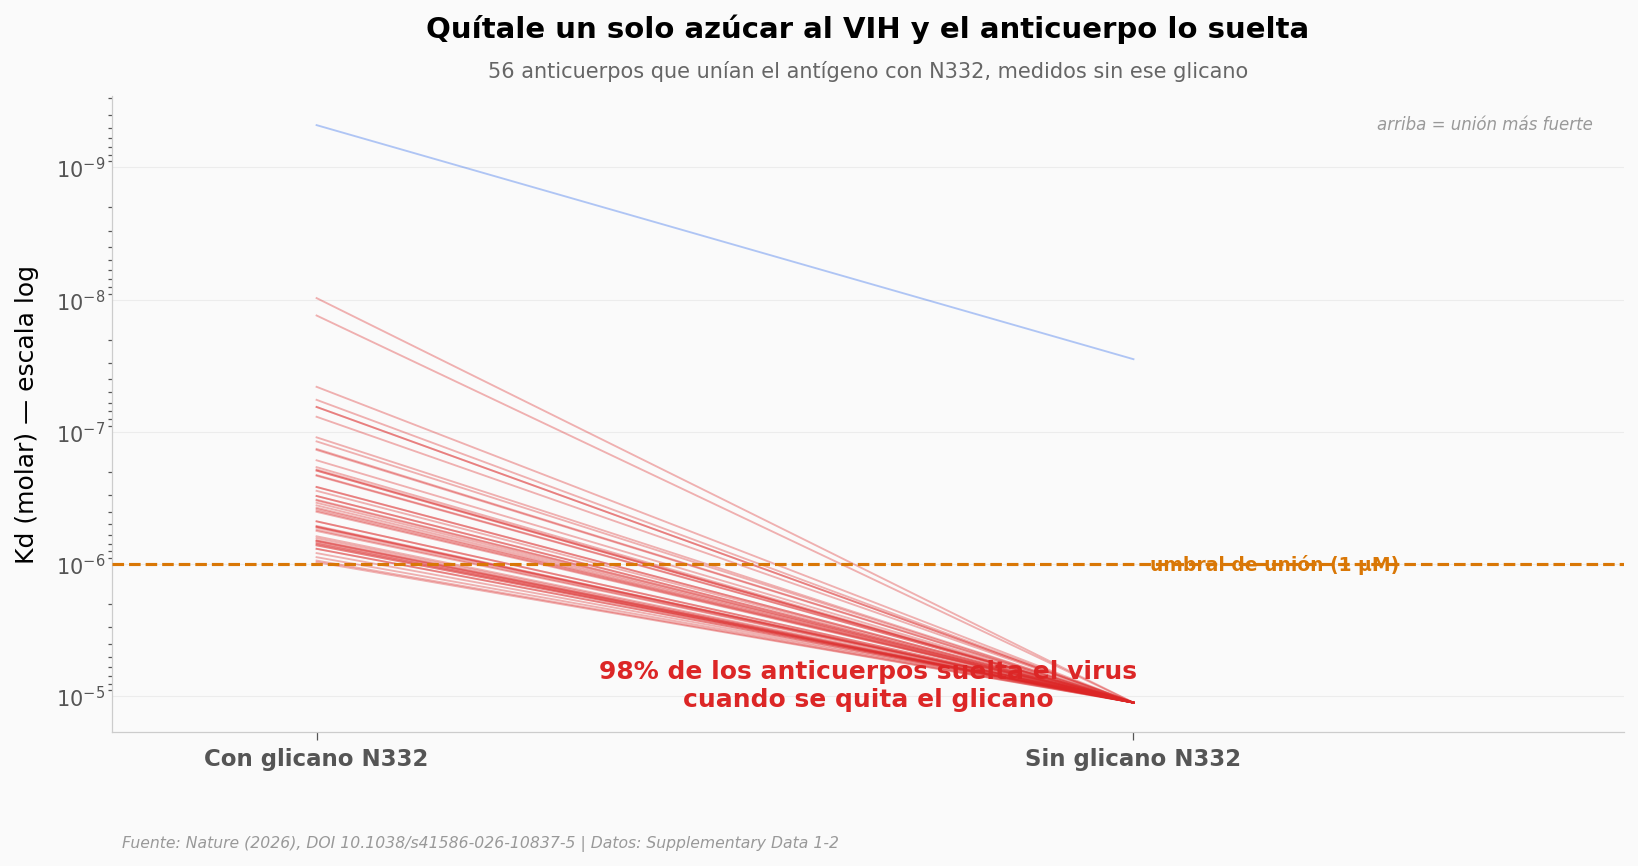

55 de 56 anticuerpos (98.2%) pierden la unión sin el glicano N332


In [3]:
# Solo los anticuerpos que SÍ unían el antígeno con el glicano (Kd < 1 µM)
binders = ctrl[ctrl['kd_con_n332'] < UMBRAL_UNION].copy()
pierde = int(binders['pierde_union'].sum())
pct_pierde = 100 * pierde / len(binders)

fig, ax = plt.subplots(figsize=(13, 5.5))
for _, r in binders.iterrows():
    perdio = r['pierde_union'] == 1
    ax.plot([0, 1], [r['kd_con_n332'], r['kd_sin_n332']],
            color=(COLOR_ALERTA if perdio else COLOR_DATOS),
            alpha=0.35, lw=0.9, zorder=3)

ax.axhline(UMBRAL_UNION, color=COLOR_REFERENCIA, ls='--', lw=1.5, zorder=4)
ax.text(1.02, UMBRAL_UNION, 'umbral de unión (1 µM)', fontsize=9,
        color=COLOR_REFERENCIA, va='center', fontweight='bold')
ax.set_yscale('log')
ax.invert_yaxis()  # arriba = unión más fuerte (Kd más baja)

ax.set_xlim(-0.25, 1.6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Con glicano N332', 'Sin glicano N332'], fontsize=11, fontweight='bold')
ax.text(0.5, 0.04, f'{pct_pierde:.0f}% de los anticuerpos suelta el virus\ncuando se quita el glicano',
        transform=ax.transAxes, ha='center', fontsize=12, fontweight='bold', color=COLOR_ALERTA)
ax.text(0.98, 0.97, 'arriba = unión más fuerte', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='#999999', style='italic')

ax.set_title('Quítale un solo azúcar al VIH y el anticuerpo lo suelta',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(binders)} anticuerpos que unían el antígeno con N332, medidos sin ese glicano',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Kd (molar) — escala log')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/control_n332.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'{pierde} de {len(binders)} anticuerpos ({pct_pierde:.1f}%) pierden la unión sin el glicano N332')

## La amplitud no es pareja

Le apuntan al blanco correcto y maduran con el tiempo. Pero "amplio" no quiere decir "universal". Cuando miramos aislado por aislado, algunos VIH caen casi siempre y otros se resisten incluso frente a los anticuerpos ya maduros.

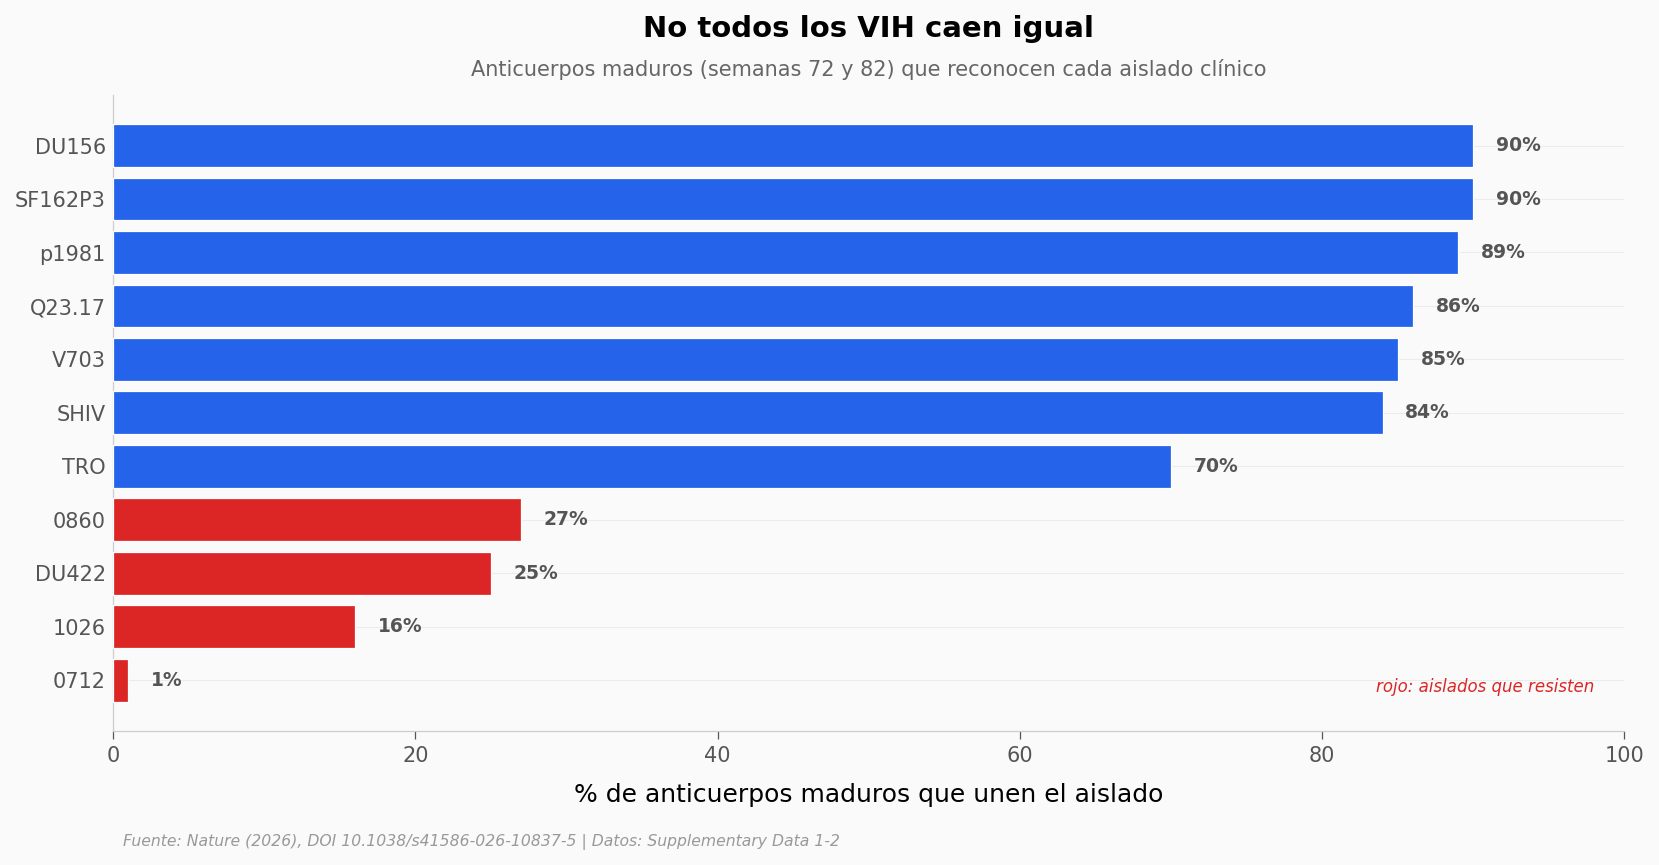

In [4]:
orden = uni.sort_values('pct_unidos')
colores = [COLOR_ALERTA if p < 40 else COLOR_DATOS for p in orden['pct_unidos']]

fig, ax = plt.subplots(figsize=(13, 5.5))
barras = ax.barh(orden['aislado'], orden['pct_unidos'], color=colores,
                 edgecolor='white', linewidth=0.6, zorder=3)
for barra, p in zip(barras, orden['pct_unidos']):
    ax.text(p + 1.5, barra.get_y() + barra.get_height() / 2, f'{int(p)}%',
            va='center', fontsize=9, color='#555555', fontweight='bold')

ax.set_title('No todos los VIH caen igual',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Anticuerpos maduros (semanas 72 y 82) que reconocen cada aislado clínico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('% de anticuerpos maduros que unen el aislado')
ax.set_xlim(0, 100)
ax.text(0.98, 0.06, 'rojo: aislados que resisten', transform=ax.transAxes,
        ha='right', fontsize=8, color=COLOR_ALERTA, style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/amplitud_por_aislado.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan amplios son, en conjunto?

La gráfica de la mediana cuenta el centro de la historia, pero esconde la forma. Si tomamos cada anticuerpo maduro por separado y contamos a cuántos de los 11 VIH se pega, ¿cómo se reparten?

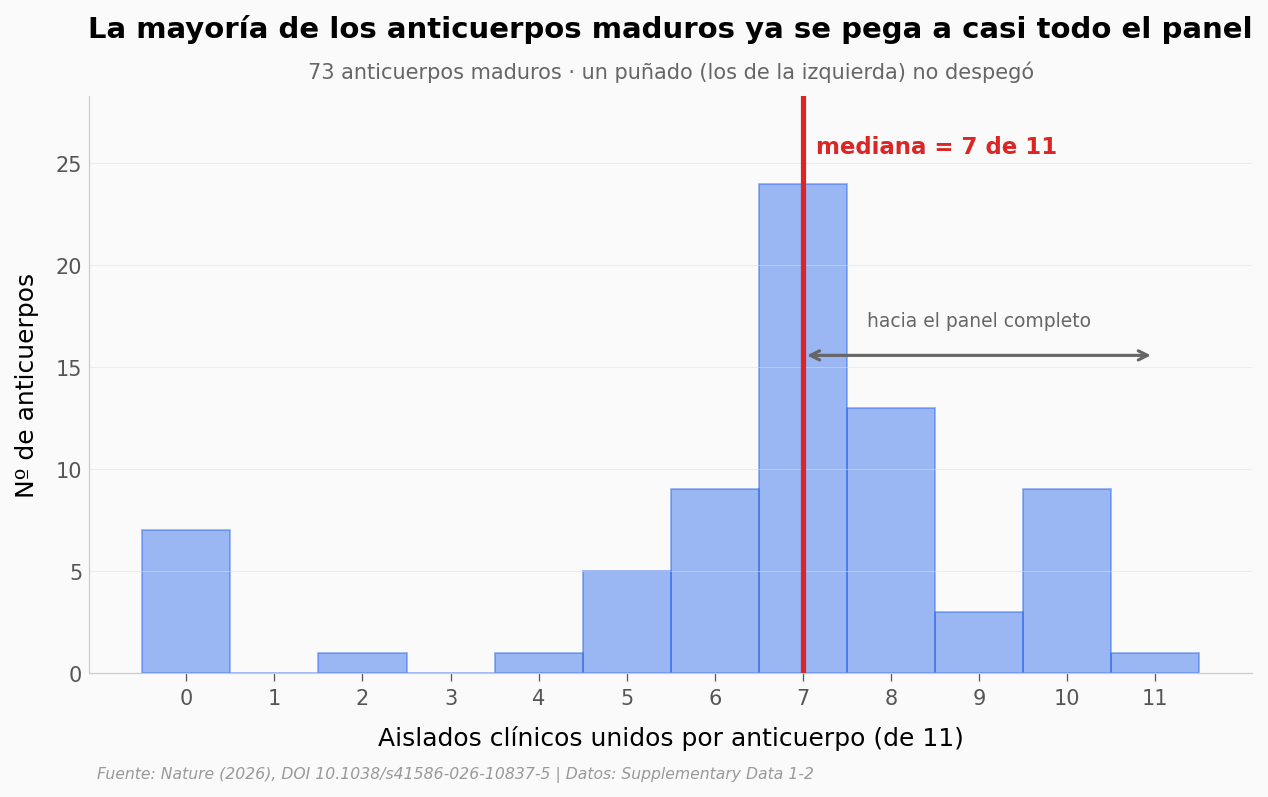

73 anticuerpos maduros | mediana 7 de 11 aislados | 7 no unieron ninguno


In [5]:
# Amplitud de cada anticuerpo maduro (semanas 72 y 82), contando aislados clínicos unidos
maduros = kd[kd['semana'].isin([72, 82]) & (kd['tipo'] == 'aislado_clinico')]
amplitud_ab = maduros.groupby('antibody_short')['se_une'].sum()
mediana = amplitud_ab.median()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(amplitud_ab, bins=range(0, 13), color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.9, align='left')
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)
ax.axvline(mediana, color=COLOR_ALERTA, lw=2.5, zorder=5)
ax.text(mediana + 0.15, y_max * 0.9, f'mediana = {int(mediana)} de {PANEL_AISLADOS}',
        color=COLOR_ALERTA, fontweight='bold', fontsize=11)
ax.annotate('', xy=(PANEL_AISLADOS, y_max * 0.55), xytext=(mediana, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana + PANEL_AISLADOS) / 2, y_max * 0.6, 'hacia el panel completo',
        ha='center', fontsize=9, color='#666666')

ax.set_title('La mayoría de los anticuerpos maduros ya se pega a casi todo el panel',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(amplitud_ab)} anticuerpos maduros · un puñado (los de la izquierda) no despegó',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Aislados clínicos unidos por anticuerpo (de 11)')
ax.set_ylabel('Nº de anticuerpos')
ax.set_xticks(range(0, 12))
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_amplitud.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'{len(amplitud_ab)} anticuerpos maduros | mediana {int(mediana)} de {PANEL_AISLADOS} aislados '
      f'| {(amplitud_ab == 0).sum()} no unieron ninguno')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| El cebador engancha a los precursores | ✅ | Kd mediana ≈ 57 pM (picomolar); el 100% de los 239 anticuerpos medidos se une (<1 µM) al inmunógeno cebador |
| La amplitud de unión madura con el tiempo | ✅ | Mediana de aislados unidos: 0 (sem. 12) → 4 (sem. 56) → 7 de 11 (sem. 82). n = 36–56 por semana |
| Le apuntan al supersitio del glicano N332 | ✅ | 55 de 56 anticuerpos (98%) pierden la unión al quitar el glicano N332 — el epítopo era el buscado |
| Firma estructural tipo BG18 | ✅ | HCDR3 larga: mediana 21 aminoácidos (rango 20–24), n = 292 en 17 primates — coincide con la clase de anticuerpo esperada |
| La amplitud es *parcial*, no universal | ⚠️ | Por aislado va del 90% (SF162P3, DU156) al 1% (0712); cuatro aislados resisten (0712, 0860, 1026, DU422) aun en anticuerpos maduros |
| Neutralización (matar el virus) | ❌ no verificado aquí | Los % de neutralización del paper (hasta 67% de amplitud; bnAb en ≥50% de los animales) viven en tablas del suplemento no públicas. Aquí medimos **unión**, el paso previo — no la neutralización |

> **Limitaciones:** (1) Todo lo que graficamos es **unión** (afinidad SPR), no neutralización viral. (2) Es un estudio en **primates no humanos**, no en personas — prueba de concepto, no una vacuna lista. (3) El panel son 11 aislados clínicos; la amplitud "hasta 67%" del paper es contra un panel de referencia distinto. (4) La semana 95 tiene n=11 y no debe leerse como una caída real.

## Ahora tú

Los datos están cargados. Tres preguntas para explorar:

1. **¿Cuáles son los aislados más difíciles?** Ordena `uni` por `pct_unidos` y mira la cola baja. ¿Qué tienen en común 0712, 0860, 1026 y DU422? *(pista: `uni.sort_values('pct_unidos').head(4)`)*
2. **¿Cambia la mediana de amplitud si bajas el umbral de unión?** Vuelve a `kd`, filtra `kd_molar < 1e-7` (unión 10× más exigente) y recuenta la amplitud por anticuerpo. *(pista: reusa el bloque de la celda del histograma cambiando `se_une` por tu propio filtro)*
3. **¿Qué tan larga es una HCDR3 "normal"?** La celda de abajo dibuja la firma estructural de estos anticuerpos. Compárala mentalmente con una HCDR3 humana típica (~15 aminoácidos): estos son notablemente más largos.

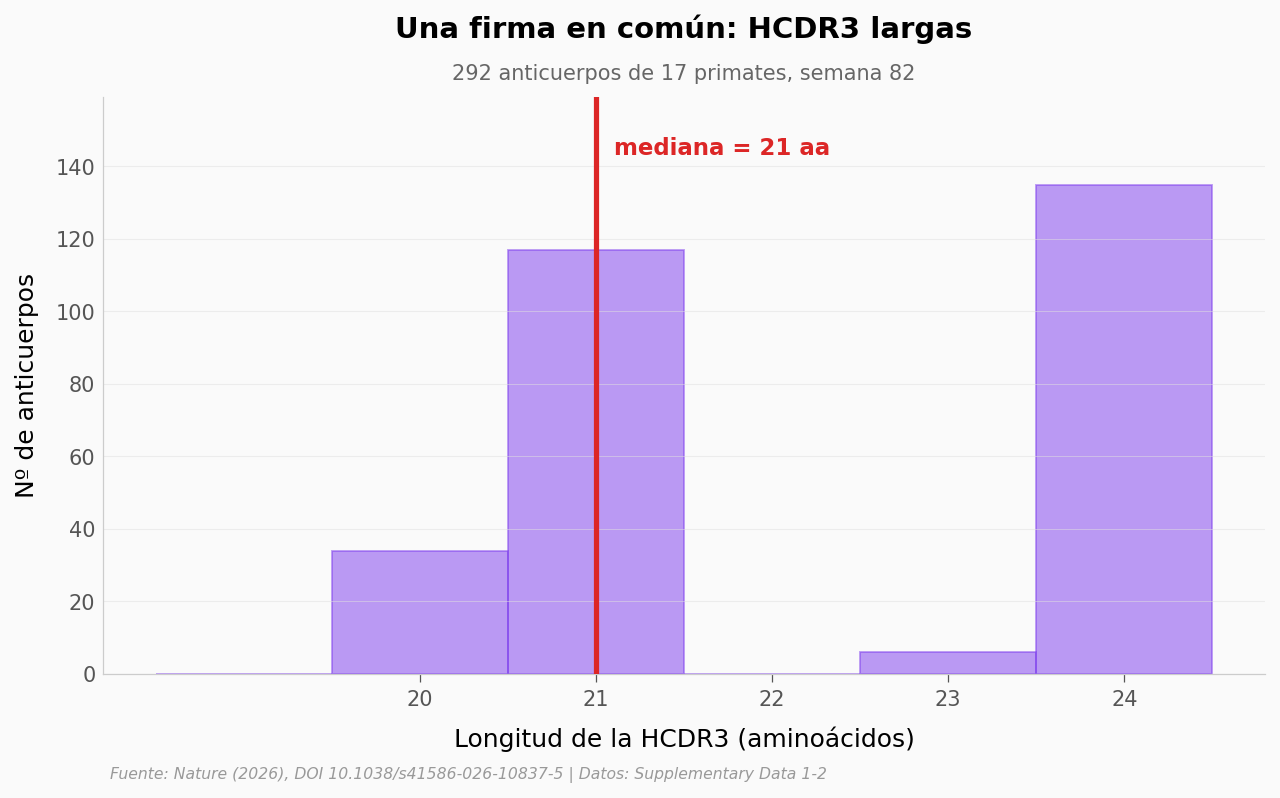

HCDR3: mediana 21 aa, rango 20-24 aa


In [6]:
# --- EXPERIMENTA AQUÍ ---
# La firma estructural: longitud de la HCDR3 (el "dedo" del anticuerpo que atraviesa el escudo de glicanos)
longitudes = cdr['cdr3_longitud']
mediana_cdr3 = longitudes.median()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(longitudes, bins=range(19, 26), color=COLOR_VIOLETA, alpha=0.5,
                           edgecolor=COLOR_VIOLETA, linewidth=0.9, align='left')
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)
ax.axvline(mediana_cdr3, color=COLOR_ALERTA, lw=2.5, zorder=5)
ax.text(mediana_cdr3 + 0.1, y_max * 0.9, f'mediana = {int(mediana_cdr3)} aa',
        color=COLOR_ALERTA, fontweight='bold', fontsize=11)

ax.set_title('Una firma en común: HCDR3 largas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(longitudes)} anticuerpos de {cdr["nhp_id"].nunique()} primates, semana 82',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud de la HCDR3 (aminoácidos)')
ax.set_ylabel('Nº de anticuerpos')
ax.set_xticks(range(20, 25))
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/firma_cdr3.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'HCDR3: mediana {int(mediana_cdr3)} aa, rango {int(longitudes.min())}-{int(longitudes.max())} aa')

## Fuentes

**Paper**: [Vaccination elicits HIV broadly neutralizing antibodies in primates](https://doi.org/10.1038/s41586-026-10837-5)  
*Nature, 2026-06-30 · paywall*

**Datos**: [Supplementary Data 2 — constantes de disociacion Kd medidas por SPR](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10837-5/MediaObjects/41586_2026_10837_MOESM4_ESM.xlsx)  
*Nature (mismo DOI) — matriz anticuerpo x inmunogeno, control del glicano N332*

**Datos**: [Supplementary Data 1 — alineamiento de HCDR3 (semana 82, clase BG18 tipo I)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10837-5/MediaObjects/41586_2026_10837_MOESM3_ESM.xlsx)

*12 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*